# 0. Preparação

In [11]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import cdist


In [12]:
df=pd.read_csv('sleep_mobile_stress_dataset_15000.csv')
df = df[['user_id', 'stress_level', 'mental_fatigue_score', 'daily_screen_time_hours', 'sleep_quality_score']]
df.describe()

,user_id,stress_level,mental_fatigue_score,daily_screen_time_hours,sleep_quality_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,6.980247,6.873009,5.501528,6.246362
std,4330.271354,2.749382,2.730482,2.600085,1.713644
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3750.750000,4.750000,4.700000,3.260000,5.000000
50%,7500.500000,7.380000,7.380000,5.490000,6.250000
75%,11250.250000,10.000000,9.450000,7.760000,7.500000
max,15000.000000,10.000000,10.000000,10.000000,10.000000


In [13]:
# Variáveis categóricas: OneHotEncoder porque nem occupation nem gender têm uma ordem natural
# categorical_columns = ['occupation', 'gender']
# encoder = OneHotEncoder(sparse_output=False)
# one_hot_encoded = encoder.fit_transform(df[categorical_columns])
# one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

# data = pd.concat([df, one_hot_df], axis=1)
# data = data.drop(['occupation', 'gender'], axis=1)

#
---

# 1. Divisão do Stress Level

### 1.1 K-Means

In [14]:
#K-Means
def apply_kmeans(df, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df[['stress_level']])
    
    centroids = kmeans.cluster_centers_.flatten()
    order = centroids.argsort()
    label_map = {order[i]: i for i in range(k)}
    
    labels = pd.Series(kmeans.labels_).map(label_map)
    return labels, sorted(centroids)

df['stress_2class_km'],  centroids_2  = apply_kmeans(df, 2)
df['stress_5class_km'],  centroids_5  = apply_kmeans(df, 5)
df['stress_10class_km'], centroids_10 = apply_kmeans(df, 10)

for k, col_km, centroids in [
    (2,  'stress_2class_km',  centroids_2),
    (5,  'stress_5class_km',  centroids_5),
    (10, 'stress_10class_km', centroids_10),
]:
    print(f"{k} classes:")
    print(f"Centroides: {[round(c, 2) for c in centroids]}")
    km_ranges = df.groupby(col_km)['stress_level'].agg(['min', 'max', 'count'])
    print(km_ranges)
    print()

2 classes:
Centroides: [np.float64(4.21), np.float64(9.08)]
                   min    max  count
stress_2class_km                    
0                 1.00   6.64   6451
1                 6.65  10.00   8549

5 classes:
Centroides: [np.float64(2.0), np.float64(4.07), np.float64(5.97), np.float64(7.89), np.float64(9.83)]
                   min    max  count
stress_5class_km                    
0                 1.00   3.03   1582
1                 3.04   5.01   2552
2                 5.02   6.93   2688
3                 6.94   8.86   2776
4                 8.87  10.00   5402

10 classes:
Centroides: [np.float64(1.36), np.float64(2.58), np.float64(3.6), np.float64(4.56), np.float64(5.47), np.float64(6.36), np.float64(7.26), np.float64(8.16), np.float64(9.03), np.float64(9.96)]
                    min    max  count
stress_10class_km                    
0                  1.00   1.97    706
1                  1.98   3.08    928
2                  3.09   4.08   1194
3                  4.09 

### 1.2 Equal-Frequency Binning

In [15]:
# Equal-Frequency Binning
df['stress_2class']  = pd.qcut(df['stress_level'], q=2,  labels=[0,1])
#df['stress_5class']  = pd.qcut(df['stress_level'], q=5,  labels=[0,1,2,3,4])               <- ERRO: "Bin edges must be unique: Index([1.0, 4.22, 6.34, 8.46, 10.0, 10.0]"
#df['stress_10class'] = pd.qcut(df['stress_level'], q=10, labels=[0,1,2,3,4,5,6,7,8,9])     <- ERRO: "Bin edges must be unique: Index([1.0, 2.94, 4.22, 5.29, 6.34, 7.38, 8.46, 9.52, 10.0, 10.0, 10.0]"
    
    #solução possível: dropar duplicates. mas isso faria: na divisão de 5 ficarmos com 4 labels e na divisão de 10 ficarmos com 8 labels
        #portanto: inviável.

In [16]:
print("2 classes:")
print(df['stress_2class'].value_counts().sort_index())
print("\nRanges:")
print(pd.qcut(df['stress_level'], q=2).value_counts().sort_index())

2 classes:
stress_2class
0    7504
1    7496
Name: count, dtype: int64

Ranges:
stress_level
(0.999, 7.38]    7504
(7.38, 10.0]     7496
Name: count, dtype: int64


Relativamente ao bloco de código de cima (Equal-Frequency Binning):
- Para o Problema C (10 classes), a abordagem inicial foi usar equal-frequency binning com pd.qcut(q=10), que divide os dados em 10 grupos com aproximadamente 10% da população cada (~1500 instâncias por classe). O objectivo era garantir classes equilibradas para o treino dos modelos.
- O método falhou com um ValueError indicando que os limites dos bins não são únicos. Concretamente, os percentis 80%, 90% e 100% coincidem todos no valor 10.0:
Index([1.0, 2.94, 4.22, 5.29, 6.34, 7.38, 8.46, 9.52, 10.0, 10.0, 10.0])
- A distribuição do stress_level é fortemente assimétrica, com aproximadamente 30% dos dados concentrados no valor máximo (10.0). Isso significa que os três últimos decis — que deveriam corresponder a classes distintas — têm todos o mesmo limite superior de 10.0, tornando impossível distingui-los como intervalos separados.
- Esta falha é em si um achado relevante sobre os dados: a concentração no valor 10 impede uma divisão equal-frequency em 10 classes verdadeiramente distintas. A solução adoptada foi usar duplicates='drop', que descarta os bins impossíveis, resultando em menos de 10 classes — o que deve ser reportado e justificado.
- a conclusão correcta: a distribuição dos dados não permite equal-frequency puro com 5 ou 10 classes distintas. Isso não é um problema do código, é uma característica dos dados que precisam de ser reportada.
<br><br>"Tentou-se aplicar equal-frequency binning, mas a concentração de ~30% dos dados no valor máximo (10.0) impossibilita criar bins com limites únicos para 5 e 10 classes. O K-Means foi adoptado por ser robusto a esta assimetria."

#
---

# 3. Cenário A - Classificação Binária

## Treino/Teste e Scale

In [17]:
# Copiar os targets de df para data
# for col in ['stress_5class_km']:
#     data[col] = df[col].values
    
# y = data['stress_5class_km']
# X = data.drop(['stress_level', 'stress_5class_km', 'user_id'], axis=1)

y = df['stress_5class_km']  
X = df[['mental_fatigue_score', 'daily_screen_time_hours', 'sleep_quality_score']]
print(X.columns)

print(X.columns)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Index(['mental_fatigue_score', 'daily_screen_time_hours',
       'sleep_quality_score'],
      dtype='object')
Index(['mental_fatigue_score', 'daily_screen_time_hours',
       'sleep_quality_score'],
      dtype='object')


In [18]:
scaler = StandardScaler()
columns_to_scale = [
    #'age',
    'daily_screen_time_hours',
    #'phone_usage_before_sleep_minutes',
    #'sleep_duration_hours',
    'sleep_quality_score',
    #'caffeine_intake_cups',
    #'physical_activity_minutes',
    #'notifications_received_per_day'#,
    'mental_fatigue_score'
]

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# print("X_train head after scaling:")
# print(X_train.head())
# print(X_train.shape)

## Baseline
A abordagem realista para 3 minutos
Baselines — sem Optuna, sem CV, hiperparâmetros fixos razoáveis:

### 1. Decision Trees

F1 no Teste: 0.7566
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       475
           1       0.70      0.62      0.66       766
           2       0.62      0.69      0.65       806
           3       0.63      0.65      0.64       833
           4       0.93      0.89      0.91      1620

    accuracy                           0.75      4500
   macro avg       0.72      0.73      0.73      4500
weighted avg       0.76      0.75      0.76      4500



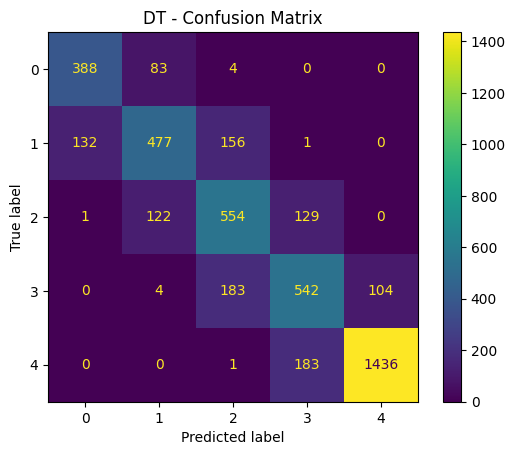

In [19]:
final_dt = DecisionTreeClassifier(
    max_depth=10, criterion='gini',
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42
)
final_dt.fit(X_train, y_train)
y_pred_dt = final_dt.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("DT - Confusion Matrix"); plt.show()

### 2. KNN

F1 no Teste: 0.7775
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       475
           1       0.72      0.69      0.70       766
           2       0.66      0.67      0.66       806
           3       0.68      0.65      0.66       833
           4       0.91      0.93      0.92      1620

    accuracy                           0.78      4500
   macro avg       0.75      0.75      0.75      4500
weighted avg       0.78      0.78      0.78      4500



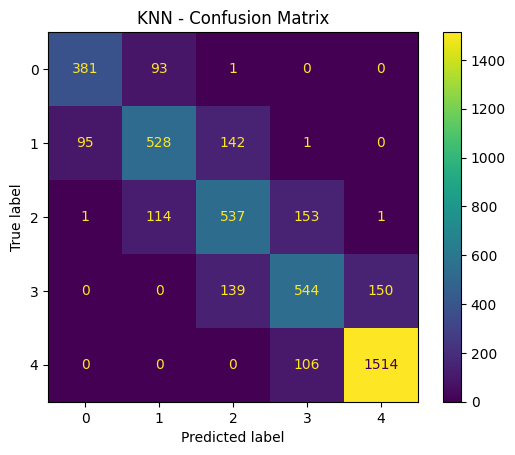

In [20]:
#O que foi feito: Optuna com hiperparâmetros: n_neighbors (3-30), weights (uniform/distance), metric (euclidean/manhattan/minkowski).
#3 trials ainda é pouco
#minkowski sem especificar p é equivalente a euclidean (p=2 por defeito). Estás a dar ao Optuna uma opção que é duplicada. Podes remover minkowski ou adicionar um p como hiperparâmetro separado.
#KNN não suporta class_weight — e o código não tenta usá-lo, o que está correto. Mas significa que o KNN é mais sensível ao desequilíbrio de classes do que os outros modelos. Podia ser mencionado no relatório.

final_knn = KNeighborsClassifier(n_neighbors=11, weights='distance', metric='euclidean')
final_knn.fit(X_train, y_train)
y_pred_knn = final_knn.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN - Confusion Matrix"); plt.show()

### 3. Naive Bayes

F1 no Teste: 0.7962
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       475
           1       0.73      0.70      0.71       766
           2       0.70      0.70      0.70       806
           3       0.70      0.72      0.71       833
           4       0.93      0.93      0.93      1620

    accuracy                           0.80      4500
   macro avg       0.77      0.77      0.77      4500
weighted avg       0.80      0.80      0.80      4500



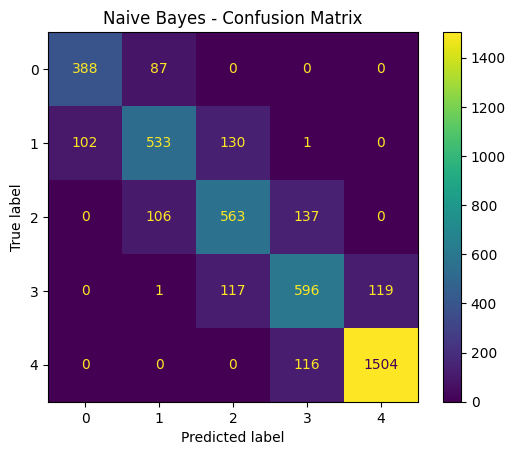

In [21]:
#Naive Bayes tem efetivamente poucos hiperparâmetros. O único relevante seria var_smoothing (suavização de variância), que podias tunar com Optuna se quisesses, mas não é obrigatório.
#GaussianNB não suporta class_weight. Para lidar com desequilíbrio podes usar priors manualmente para definir probabilidades a priori das classes. Mas para o relatório basta mencionar que o NB não tem suporte nativo para classes desbalanceadas.

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)

print(f"F1 no Teste: {f1_score(y_test, y_pred_nb, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_nb))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naive Bayes - Confusion Matrix"); plt.show()

## Modelos
Modelos principais — Optuna com validation split, SEM cross_val_score:

### 1. NN

[I 2026-05-20 13:30:44,799] A new study created in memory with name: no-name-37578933-54f4-4115-b429-e9e2a771eb88
[I 2026-05-20 13:30:48,240] Trial 0 finished with value: 0.7999542395667332 and parameters: {'n_layers': 3, 'n_units_l0': 45, 'n_units_l1': 37, 'n_units_l2': 126, 'lr': 0.01624473069249046, 'activation': 'relu'}. Best is trial 0 with value: 0.7999542395667332.
[I 2026-05-20 13:30:49,706] Trial 1 finished with value: 0.8018487329665058 and parameters: {'n_layers': 2, 'n_units_l0': 57, 'n_units_l1': 35, 'lr': 0.00877815280711437, 'activation': 'tanh'}. Best is trial 1 with value: 0.8018487329665058.
c:\Users\ruizi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2026-05-20 13:31:01,585] Trial 2 finished with value: 0.784801932684158 and parameters: {'n_layers': 3, 'n_units_l0': 

Melhor F1 (val): 0.8108
Hiperparâmetros: {'n_layers': 1, 'n_units_l0': 25, 'lr': 0.00017401934182723446, 'activation': 'tanh'}
F1 no Teste: 0.7939
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       475
           1       0.73      0.70      0.72       766
           2       0.70      0.70      0.70       806
           3       0.71      0.67      0.69       833
           4       0.91      0.94      0.92      1620

    accuracy                           0.80      4500
   macro avg       0.77      0.77      0.77      4500
weighted avg       0.79      0.80      0.79      4500



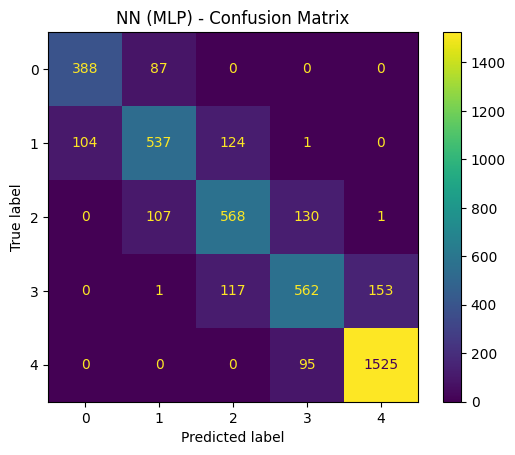

In [22]:
#O que foi feito: MLPClassifier do sklearn. Optuna com (5) trials. Hiperparâmetros: número de camadas (1-3), unidades por camada (4-128), learning rate. early_stopping=True.
# O max_iter=200 no Optuna e max_iter=500 no modelo final é inconsistente
# Não há otimização da função de ativação (activation: relu, tanh, logistic). Isto é um hiperparâmetro importante para MLPs.
# Não há otimização de momentum ou alpha (regularização L2). alpha é particularmente importante para controlar overfitting.
# early_stopping=True com cross_val_score tem uma interação subtil: o early stopping usa internamente um validation set dentro de cada fold, o que pode dar resultados ligeiramente diferentes do que esperas. Não é um erro grave, mas vale a pena estar ciente.

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_layers = [trial.suggest_int(f"n_units_l{i}", 16, 128) for i in range(n_layers)]
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])

    #?
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=trial.number
    )

    model = MLPClassifier(
        hidden_layer_sizes=tuple(hidden_layers),
        activation=activation,
        learning_rate_init=lr,
        max_iter=200,
        random_state=42,
        early_stopping=False #True?
    )
    model.fit(X_tr, y_tr)
    return f1_score(y_val, model.predict(X_val), average='weighted')

# Executar o estudo do Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)
best_trial = study.best_trial

print(f"Melhor F1 (val): {best_trial.value:.4f}")
print("Hiperparâmetros:", best_trial.params)

n_layers_best = best_trial.params['n_layers']
hidden_best = tuple(best_trial.params[f'n_units_l{i}'] for i in range(n_layers_best))
final_nn = MLPClassifier(
    hidden_layer_sizes=hidden_best,
    activation=best_trial.params['activation'],
    learning_rate_init=best_trial.params['lr'],
    max_iter=500, random_state=42, early_stopping=True
)
final_nn.fit(X_train, y_train)
y_pred_nn = final_nn.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_nn, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_nn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn)
plt.title("NN (MLP) - Confusion Matrix"); plt.show()

In [23]:
#fazer pip install nbformat

# Gráfico com o histórico da otimização
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

# Gráfico detalhando o impacto de cada hiperparâmetro
fig2 = optuna.visualization.plot_slice(study)
fig2.show()

### 2. SVM

[I 2026-05-20 13:31:24,013] A new study created in memory with name: no-name-5ee1166f-0426-47cf-97cc-ad97d5569217
[I 2026-05-20 13:31:24,084] Trial 0 finished with value: 0.7758245756791492 and parameters: {'C': 1.8497022021770961, 'kernel': 'linear'}. Best is trial 0 with value: 0.7758245756791492.
[I 2026-05-20 13:31:24,365] Trial 1 finished with value: 0.796283983767291 and parameters: {'C': 0.010043623219513527, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 1 with value: 0.796283983767291.
[I 2026-05-20 13:31:24,445] Trial 2 finished with value: 0.8086468652164013 and parameters: {'C': 9.907791880871443, 'kernel': 'linear'}. Best is trial 2 with value: 0.8086468652164013.
[I 2026-05-20 13:31:24,574] Trial 3 finished with value: 0.8090711334474769 and parameters: {'C': 2.1793401191377746, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 3 with value: 0.8090711334474769.
[I 2026-05-20 13:31:24,719] Trial 4 finished with value: 0.8102683605400497 and parameters: {'C': 24.285302173

Melhor F1 (val): 0.8114
Hiperparâmetros: {'C': 0.2046858253620014, 'kernel': 'linear'}
F1 no Teste: 0.7956
              precision    recall  f1-score   support

           0       0.75      0.84      0.80       475
           1       0.73      0.67      0.70       766
           2       0.70      0.69      0.70       806
           3       0.68      0.76      0.72       833
           4       0.95      0.90      0.93      1620

    accuracy                           0.79      4500
   macro avg       0.77      0.78      0.77      4500
weighted avg       0.80      0.79      0.80      4500



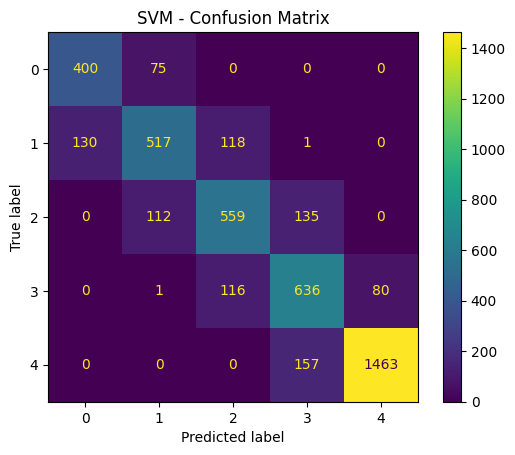

In [24]:
#O que foi feito: SVC com Optuna (5) trials. Hiperparâmetros: C (log-scale, 0.01 a 100), kernel (rbf/poly/sigmoid), gamma (scale/auto). class_weight='balanced'.
# Falta o kernel linear! Estás a testar rbf, poly e sigmoid mas não o kernel linear. Para dados tabulares normalizados, o kernel linear é frequentemente competitivo e é o mais interpretável
# O SVC por defeito usa estratégia One-vs-One (OvO) para multiclasse. Para 10 classes isso significa 45 classificadores binários treinados internamente. Funciona, mas é lento. Podes adicionar decision_function_shape='ovr' para One-vs-Rest, que é mais rápido

def objective_svm(trial):
    C      = trial.suggest_float('C', 1e-2, 1e2, log=True)
    kernel = trial.suggest_categorical('kernel', ['rbf', 'linear'])
    gamma  = 'scale' if kernel == 'linear' else trial.suggest_categorical('gamma', ['scale', 'auto'])

    rng = np.random.default_rng(trial.number)
    idx = rng.choice(len(X_train), size=3000, replace=False)
    Xs, ys = X_train.iloc[idx], y_train.iloc[idx]

    X_tr, X_val, y_tr, y_val = train_test_split(Xs, ys, test_size=0.2, stratify=ys, random_state=42)
    model = SVC(C=C, kernel=kernel, gamma=gamma, class_weight='balanced', random_state=42)
    model.fit(X_tr, y_tr)
    return f1_score(y_val, model.predict(X_val), average='weighted')

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)
best_svm = study_svm.best_trial
print(f"Melhor F1 (val): {best_svm.value:.4f}")
print("Hiperparâmetros:", best_svm.params)

final_svm = SVC(**best_svm.params, class_weight='balanced', random_state=42)
final_svm.fit(X_train, y_train)
y_pred_svm = final_svm.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_svm))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM - Confusion Matrix"); plt.show()

### 3. [ Terceiro Método ]

##### a) Random Forest

[I 2026-05-20 13:31:26,726] A new study created in memory with name: no-name-9a42273c-4e9d-4207-8a64-8ed28c4b2833
[I 2026-05-20 13:31:29,486] Trial 0 finished with value: 0.8004214089465173 and parameters: {'n_estimators': 254, 'max_depth': 18, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8004214089465173.
[I 2026-05-20 13:31:30,713] Trial 1 finished with value: 0.7870748334572358 and parameters: {'n_estimators': 105, 'max_depth': 19, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8004214089465173.
[I 2026-05-20 13:31:32,806] Trial 2 finished with value: 0.7992738547993109 and parameters: {'n_estimators': 239, 'max_depth': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8004214089465173.
[I 2026-05-20 13:31:34,785] Trial 3 finished with value: 0.7842519865868504 and parameters: {'n_estimators': 206, 'max_depth': 16, 'max_features': 'log2'}. Best is trial 0 with value: 0.8004214089465173.
[I 2026-05-20 13:31:36,996] Trial 4 finished with value: 0.79500988212

Melhor F1 (val): 0.8004
Melhores Hiperparâmetros: {'n_estimators': 254, 'max_depth': 18, 'max_features': 'sqrt'}
F1 no Teste: 0.7829
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       475
           1       0.71      0.69      0.70       766
           2       0.67      0.68      0.67       806
           3       0.69      0.67      0.68       833
           4       0.92      0.93      0.93      1620

    accuracy                           0.78      4500
   macro avg       0.76      0.75      0.75      4500
weighted avg       0.78      0.78      0.78      4500



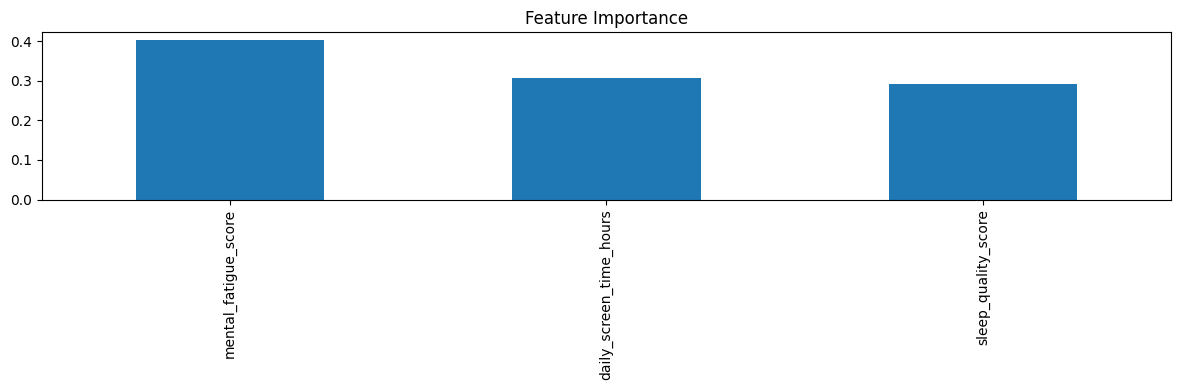

In [25]:
# O que foi feito: RandomForestClassifier com Optuna (5 trials). Hiperparâmetros: n_estimators (50-300), max_depth (3-20), min_samples_split, min_samples_leaf, max_features. class_weight='balanced'. Feature importance plot.
# max_features=None significa usar todas as features — isso é tecnicamente equivalente a uma "bagging ensemble" sem aleatoriedade de features, perdendo parte do que torna o RF robusto. Podes manter mas vale a pena notar.
# O range de max_depth (3-20) pode ser restritivo para 10 classes. Para o problema de 10 classes, podes alargar para 30.

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    max_depth    = trial.suggest_int('max_depth', 5, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=trial.number
    )
    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        max_features=max_features, class_weight='balanced', random_state=42
    )
    model.fit(X_tr, y_tr)
    return f1_score(y_val, model.predict(X_val), average='weighted')

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)
best_rf = study_rf.best_trial
print(f"Melhor F1 (val): {best_rf.value:.4f}")
print("Melhores Hiperparâmetros:", best_rf.params)

final_rf = RandomForestClassifier(**best_rf.params, class_weight='balanced', random_state=42)
final_rf.fit(X_train, y_train)
y_pred_rf = final_rf.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_rf))

importances = pd.Series(final_rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4), title='Feature Importance')
plt.tight_layout(); plt.show()

##### b) Logistic Regression

F1 no Teste: 0.7974
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       475
           1       0.74      0.68      0.71       766
           2       0.71      0.70      0.70       806
           3       0.69      0.76      0.72       833
           4       0.95      0.91      0.93      1620

    accuracy                           0.80      4500
   macro avg       0.77      0.78      0.77      4500
weighted avg       0.80      0.80      0.80      4500



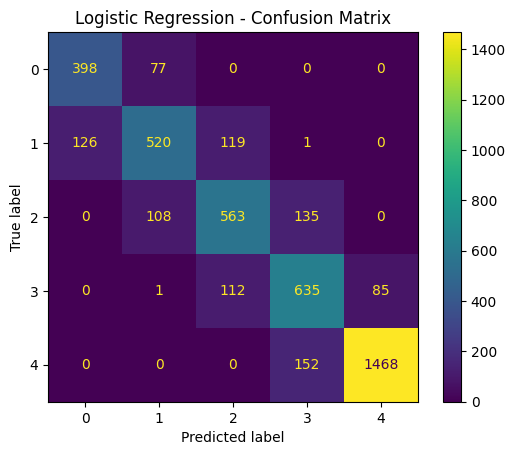

In [26]:
#O que foi feito: Optuna (5 trials). Hiperparâmetros: C, solver (lbfgs/saga). penalty='l2' hardcoded. class_weight='balanced'.
# O solver='saga' suporta tanto l1 como l2, mas o código força penalty='l2' para ambos. Isto desperdiça parte da capacidade do saga. Podias adicionar penalty como hiperparâmetro condicionado ao solver: se lbfgs → sempre l2; se saga → l1 ou l2.
# regressão logística não está nas aulas como um método de classificação explícito (o Word descreve "Regressão Linear" para outputs contínuos, não logística)
# Para multiclasse, o sklearn usa multi_class='auto' por defeito, que escolhe OvR ou multinomial dependendo do solver. Para saga podes usar multinomial explicitamente, o que é mais correto teoricamente para mais de 2 classes.

final_lr = LogisticRegression(
    C=1.0, solver='lbfgs', penalty='l2',
    class_weight='balanced', max_iter=1000, random_state=42
)
final_lr.fit(X_train, y_train)
y_pred_lr = final_lr.predict(X_test)
print(f"F1 no Teste: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_lr))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression - Confusion Matrix"); plt.show()

##### c) Clustering como Classificadores

###### c.1) K-Means

K-Means (clf) F1 no Teste: 0.6103
              precision    recall  f1-score   support

           0       0.62      0.96      0.76       475
           1       0.52      0.64      0.57       766
           2       0.00      0.00      0.00       806
           3       0.55      0.62      0.58       833
           4       0.84      0.98      0.90      1620

    accuracy                           0.68      4500
   macro avg       0.51      0.64      0.56      4500
weighted avg       0.56      0.68      0.61      4500



c:\Users\ruizi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ruizi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ruizi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

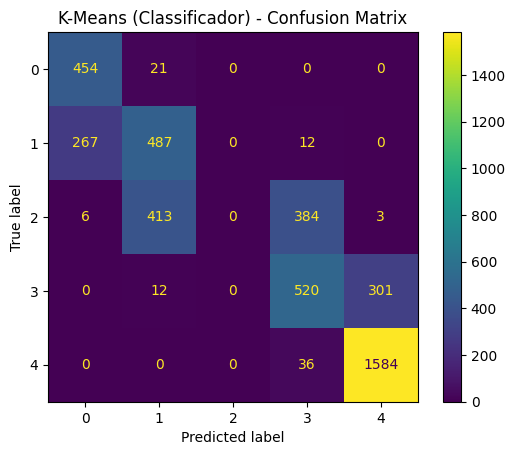

In [27]:
#O que foi feito: K-Means com k=2 nos features X. Mapeia cada cluster para a classe maioritária nos dados de treino. Prediz no teste atribuindo cada ponto ao centróide mais próximo.
# K-Means é aprendizagem não-supervisionada — não usa os labels durante o treino (errado)
# utilização criativa, mas metodologicamente fraca
# basta mudar n_clusters=5 ou n_clusters=10
km_clf = KMeans(n_clusters=5, random_state=42, n_init=10)
km_clf.fit(X_train)

# Mapear cluster → label maioritário
km_train_labels = km_clf.labels_
cluster_to_class = {}
for cluster_id in range(5):
    mask = km_train_labels == cluster_id
    majority = y_train.values[mask]
    cluster_to_class[cluster_id] = int(pd.Series(majority).mode()[0])

y_pred_km_clf = np.array([cluster_to_class[c] for c in km_clf.predict(X_test)])
print(f"K-Means (clf) F1 no Teste: {f1_score(y_test, y_pred_km_clf, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_km_clf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_km_clf)
plt.title("K-Means (Classificador) - Confusion Matrix"); plt.show()

###### c.2) AGNES (Hierarchical / Agglomerative)

REMOVIDO por causa da complexidade temporal e espacial

## Comparação

                 F1 (Teste)
Decision Tree        0.7566
KNN                  0.7775
Naive Bayes          0.7962
NN (MLP)             0.7939
SVM                  0.7956
Random Forest        0.7829
Log. Regression      0.7974
K-Means (clf)        0.6103


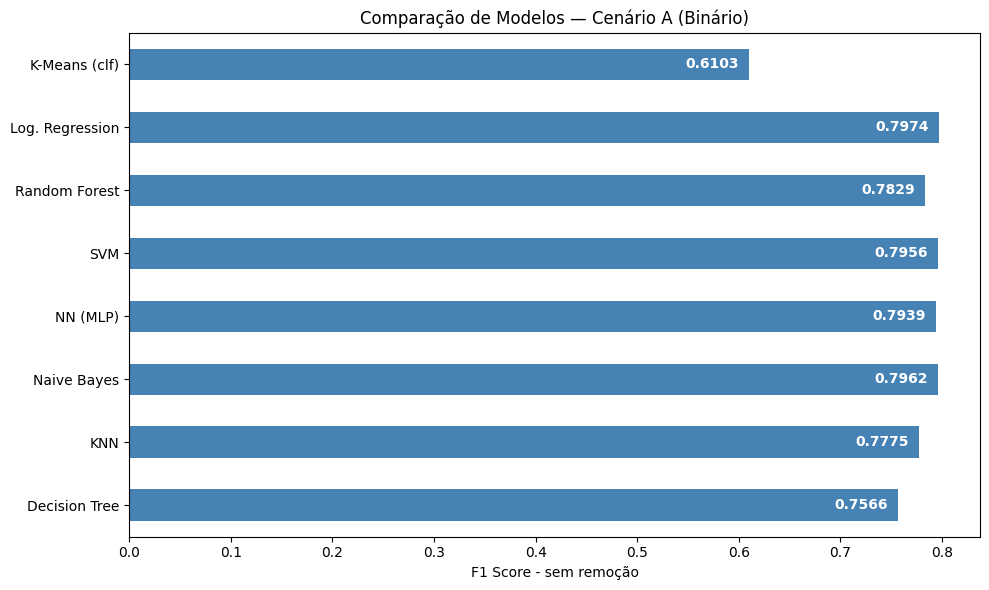

In [28]:
results = {
    'NN (MLP)':        f1_score(y_test, y_pred_nn, average='weighted'),
    'SVM':             f1_score(y_test, y_pred_svm,  average='weighted'),
    'Random Forest':   f1_score(y_test, y_pred_rf, average='weighted'),
    'Decision Tree':   f1_score(y_test, y_pred_dt, average='weighted'),
    'KNN':             f1_score(y_test, y_pred_knn, average='weighted'),
    'Naive Bayes':     f1_score(y_test, y_pred_nb, average='weighted'),
    'Log. Regression': f1_score(y_test, y_pred_lr, average='weighted'),
    'K-Means (clf)':   f1_score(y_test, y_pred_km_clf, average='weighted')
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1 (Teste)'])
desired_order = [
    'Decision Tree',
    'KNN',
    'Naive Bayes',
    'NN (MLP)',
    'SVM',
    'Random Forest',
    'Log. Regression',
    'K-Means (clf)'
]
results_df = results_df.reindex(desired_order)
print(results_df.round(4))

ax = results_df.plot(kind='barh', figsize=(10, 6), legend=False, color='steelblue')
plt.xlabel('F1 Score - sem remoção')
plt.title('Comparação de Modelos — Cenário A (Binário)')

for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.text(row['F1 (Teste)'] - 0.01, i, f"{row['F1 (Teste)']:.4f}", 
            va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.show()